<a href="https://colab.research.google.com/github/NomNomNarang/Image-Classification-ANN/blob/main/mnsit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# x_train and x_test their dimensions should be same and y_train,y_test their shape/length should be same

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
y_train.shape

(60000,)

In [7]:
x_test.shape

(10000, 28, 28)

In [8]:
##RESHAPE THE MATRIX AND ALSO NORMALIZE
x_train=x_train/255
x_test=x_test/255

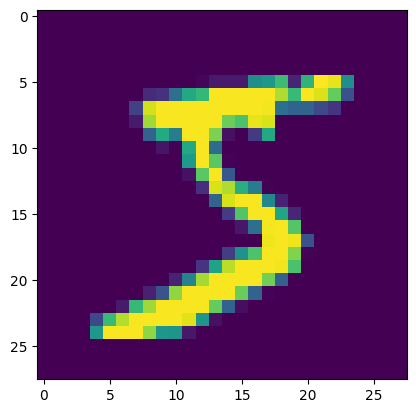

In [10]:
plt.imshow(x_train[0])

In [11]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [12]:
x_train=x_train.reshape(len(x_train),28*28)
x_test=x_test.reshape(len(x_test),28*28)

In [13]:
model=keras.Sequential([
    keras.layers.Dense(128,input_shape=(28*28,),activation='sigmoid'),
    keras.layers.Dense(10,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [16]:
model.fit(x_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8261 - loss: 0.7256 - val_accuracy: 0.9330 - val_loss: 0.2436
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9323 - loss: 0.2362 - val_accuracy: 0.9494 - val_loss: 0.1814
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9490 - loss: 0.1700 - val_accuracy: 0.9574 - val_loss: 0.1505
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9631 - loss: 0.1280 - val_accuracy: 0.9628 - val_loss: 0.1312
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9706 - loss: 0.1045 - val_accuracy: 0.9658 - val_loss: 0.1159
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9768 - loss: 0.0853 - val_accuracy: 0.9677 - val_loss: 0.1109
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9809 - loss: 0.0698 - val_accuracy: 0.9693 - val_loss: 0.1028
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9842 - loss: 0.0580 - 

In [17]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9701 - loss: 0.0925


[0.08376020938158035, 0.9736999869346619]

In [18]:
y=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [19]:
y

array([[1.6380390e-02, 2.8397387e-03, 2.7189356e-01, ..., 9.9987400e-01,
        4.9780137e-03, 3.2229513e-02],
       [3.0206678e-02, 9.0256333e-01, 9.9989092e-01, ..., 2.4525405e-06,
        9.5548153e-02, 3.3814827e-05],
       [1.1025044e-05, 9.9716902e-01, 7.9315282e-02, ..., 1.3982731e-01,
        2.5837067e-01, 4.9789355e-04],
       ...,
       [6.0244613e-05, 3.2665965e-05, 7.2338158e-04, ..., 1.6043758e-01,
        7.6363631e-02, 5.6216353e-01],
       [4.0707579e-05, 3.2413655e-03, 4.8556775e-04, ..., 2.7693815e-03,
        9.3655580e-01, 7.9643898e-05],
       [1.7409711e-01, 3.4803860e-03, 3.4588853e-01, ..., 3.6583524e-04,
        1.0371516e-02, 5.1126974e-03]], dtype=float32)

In [48]:
y_pred=np.argmax(y,axis=1)

In [25]:
y_test[0]

np.uint8(7)

In [26]:
bool (y_test[0]==np.argmax(y[0]) )

True

In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.97      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.95      0.97      0.96       974
           9       0.98      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



<Axes: >

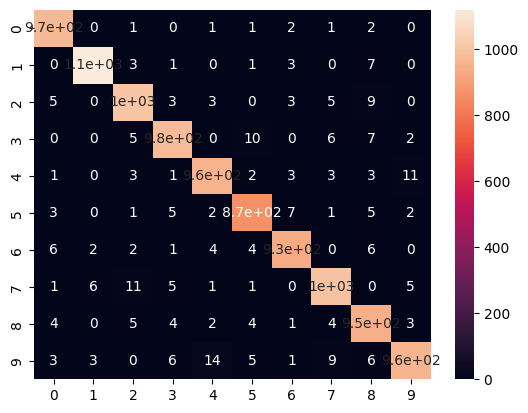

In [54]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test,np.argmax(y,axis=1)),annot=True)

In [56]:
report=classification_report(y_test,y_pred,output_dict=True)
df=pd.DataFrame(report).transpose()

<Axes: >

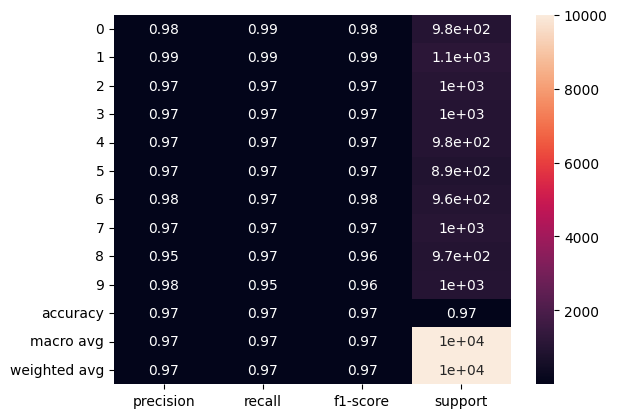

In [59]:
sns.heatmap(df,annot=True)